In [1]:
# import important libraries

import os
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image

In [14]:
# Define dataset path

dir_path = Path("D:/BTD/Brain-Tumor-Detector-and-Identifier/dataset/raw/Brain Tumor labeled dataset")

print(dir_path)
print(dir_path.exists())

D:\BTD\Brain-Tumor-Detector-and-Identifier\dataset\raw\Brain Tumor labeled dataset
True


In [ ]:
#Defining Four main classes

CLASSES = ["glioma","meningioma","notumor","pituitary"]

for class_name in CLASSES:
    class_path = dir_path / class_name
    print(class_name,"->",class_path.exists())


glioma -> True
meningioma -> True
notumor -> True
pituitary -> True


In [15]:
#Count the images

for class_name in CLASSES:
    class_path = dir_path/class_name

    images = list(class_path.glob("*.jpg"))
    print(f"{class_name}:{len(images)} images")



glioma:455 images
meningioma:550 images
notumor:550 images
pituitary:620 images


In [16]:
#Creating a Dataset summary

dataset_summary = []

for class_name in CLASSES:
    class_path = dir_path/class_name

    images = list(class_path.glob("*.jpg"))

    dataset_summary.append(
        {
            "Class" : class_name,
            "Number of Images" : len(images)
        }
    )

summary_df = pd.DataFrame(dataset_summary)

summary_df

,Class,Number of Images
0,glioma,455
1,meningioma,550
2,notumor,550
3,pituitary,620


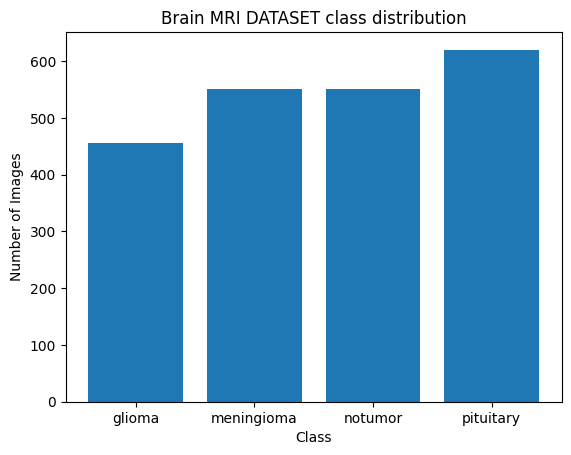

In [17]:
#visualize class distribution
plt.Figure(figsize=(8,5))

plt.bar(
    summary_df["Class"],
    summary_df["Number of Images"]
)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Brain MRI DATASET class distribution")
plt.show()

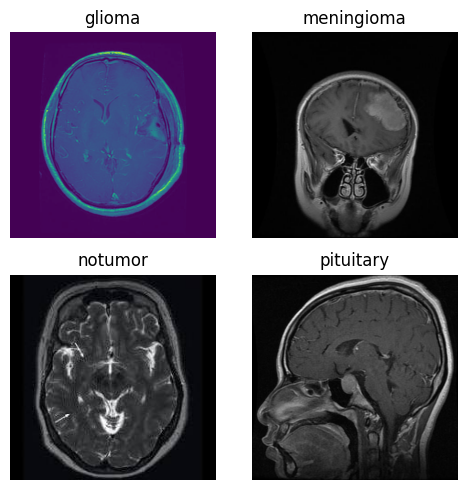

In [24]:
#Display one MRI for each class

fig,axes = plt.subplots(2,2, figsize=(5,5))

for ax,class_name in zip(axes.ravel(),CLASSES):

    class_path = dir_path/class_name

    images = list(class_path.glob("*.jpg"))
    image_path = random.choice(images)

    image = Image.open(image_path)

    ax.imshow(image)
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()